
# Session 14 — Confidence Intervals

**Goal:** Practice constructing **confidence intervals**, **one-sided bounds**, **proportion intervals**, **variance/σ intervals**, **two-sample mean difference CIs**, and a **bootstrap CI** — *using only* **NumPy**, **SciPy**, and **matplotlib**.

- When you need a critical value as in tables, use:
  - `scipy.stats.t.ppf(...)` for **t**,
  - `scipy.stats.norm.ppf(...)` for **z**,
  - `scipy.stats.chi2.ppf(...)` for **χ²**,
  - `scipy.stats.f.ppf(...)` for **F**.

### Reminders
- **Two-sided 95% CI** uses `alpha=0.05` → split **0.025** in each tail (use `ppf(1 - 0.025, df)` for t).
- **One-sided 95% upper bound** uses **0.05** in the upper tail (use `ppf(1 - 0.05, df)` for t).


In [5]:

import numpy as np
import math
from scipy import stats as st
import matplotlib.pyplot as plt
import random
np.set_printoptions(precision=6, suppress=True)



---
## Exercise 1 — Bootstrap CI for a mean (percentile method)

**Objective:** Construct a **95% bootstrap confidence interval** for the mean using the **percentile method**, and compare with the classical **t-based** CI.

We will use the following sample (rod diameters in mm), but you may replace it with any sample of your choice.


Sample mean = 8.234000
Bootstrap 95% CI (percentile) = (8.221333, 8.246000)


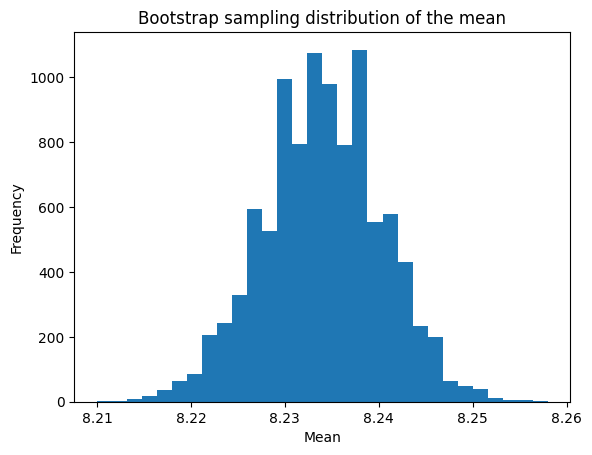

Classical t-based 95% CI = (8.220465, 8.247535)


In [7]:

# ---------- Student Task ----------
# 1) Store the sample in a NumPy array x.
# 2) Set B = 10000 bootstrap resamples.
# 3) For b in 0..B-1:
#       - Draw a bootstrap sample of size n WITH REPLACEMENT.
#       - Compute and store the mean of that resample.
# 4) Compute the 2.5th and 97.5th percentiles of the bootstrap means.
# 5) Plot a histogram of the bootstrap means (one plot).
# 6) Compute and print the classical t-based 95% CI for comparison.
#

x = np.array([8.24, 8.25, 8.20, 8.23, 8.24, 8.21, 8.26, 8.26, 8.20,
              8.25, 8.23, 8.23, 8.19, 8.28, 8.24], dtype=float)


B = 10000
n = np.size(x)
boot_means = np.empty(B, dtype=float)

#Do a loop with size B
for b in range(B):
    #Select n random values from x, with replacement.
    idx = np.array(random.choices(range(n), k=n))
    xb = x[idx]
    boot_means[b] = np.mean(xb)

#Take lower and upper percentile
lower = np.percentile(boot_means, 2.5)
upper = np.percentile(boot_means, 97.5)
xbar = np.mean(x)

print(f"Sample mean = {xbar:.6f}")
print(f"Bootstrap 95% CI (percentile) = ({lower:.6f}, {upper:.6f})")

# histogram
plt.figure()
plt.hist(boot_means, bins=30)
plt.title("Bootstrap sampling distribution of the mean")
plt.xlabel("Mean")
plt.ylabel("Frequency")
plt.show()

# Classical t-based CI
s = np.std(x)
se = s / np.sqrt(n)
tcrit = st.t.ppf(1 - 0.05/2, n-1)
ci_t = (xbar - tcrit*se, xbar + tcrit*se)
print(f"Classical t-based 95% CI = ({ci_t[0]:.6f}, {ci_t[1]:.6f})")



---
## Exercise 2 — CI for a population mean; required sample size

**Scenario:** A population has size 6000. You sample **n = 49** adults and obtain **mean = 170 cm**, **s = 25 cm**.

1) Compute the **95% CI** for the average height.  
2) The margin (~7 cm) is too large; you want a margin of **3 cm**. What is the **smallest sample size** you need? (Use **z** for planning.)


In [8]:

xbar = 170.0
s = 25.0
n = 49
df = n - 1
alpha = 0.05

tcrit = st.t.ppf(1 - alpha/2, df)
se = s / np.sqrt(n)
me = tcrit * se
ci = (xbar - me, xbar + me)
print(f"(1) 95% CI (t-based, df={df}): ({ci[0]:.3f}, {ci[1]:.3f}),  ME={me:.3f} cm")

# Planning sample size for margin 3 cm using z
zcrit = st.norm.ppf(1 - alpha/2)
m_target = 3.0
n_req = math.ceil((zcrit * s / m_target) ** 2) #ceil to round
print(f"(2) Smallest n for margin ≤ 3 cm (planning with z): n ≥ {n_req}")


(1) 95% CI (t-based, df=48): (162.819, 177.181),  ME=7.181 cm
(2) Smallest n for margin ≤ 3 cm (planning with z): n ≥ 267



---
## Exercise 3 — CI for a mean with unknown σ (small sample)

Given: \(n = 22\), sample mean \( $\bar{x} = 13.71$\), sample sd \( s = 3.55\).  
Compute the **95% CI** for the population mean using **t**.


In [10]:

# ---------- Student Task ----------
xbar = 13.71
s = 3.55
n = 22
df = n - 1
alpha = 0.05

tcrit = st.t.ppf(1 - alpha/2, df)
se = s / np.sqrt(n)
me = tcrit * se
ci = (xbar - me, xbar + me)

print(f"95% CI for the mean (df={df}): ({ci[0]:.3f}, {ci[1]:.3f})")


95% CI for the mean (df=21): (12.136, 15.284)



---
## Exercise 4 — Rod diameters: normality, two-sided CI, one-sided upper bound

Data (mm):  
8.24 8.25 8.20 8.23 8.24 8.21 8.26 8.26 8.20 8.25 8.23 8.23 8.19 8.28 8.24

**Tasks:**
1) **Normality checks**: make a **histogram**
2) Compute the **two-sided 95% CI** for the mean (t-based).  
3) Compute the **one-sided 95% upper confidence bound** for the mean.  



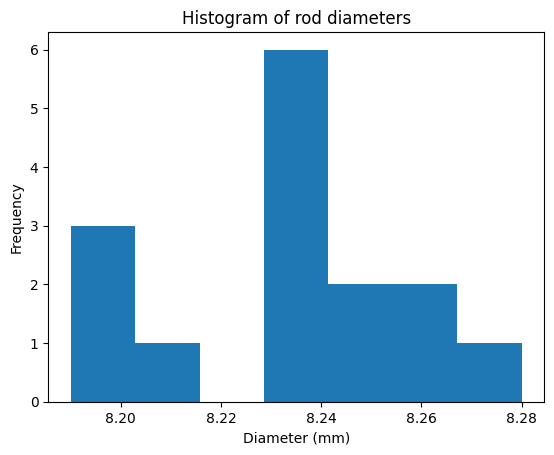

mean  : 8.234
median: 8.24
mode  : 8.23
Two-sided 95% CI for mean: (8.219990, 8.248010)
One-sided 95% upper bound on mean: 8.245505


In [14]:
x = np.array([8.24, 8.25, 8.20, 8.23, 8.24, 8.21, 8.26, 8.26, 8.20,
              8.25, 8.23, 8.23, 8.19, 8.28, 8.24], dtype=float)
n = x.size
df = n - 1
alpha = 0.05

# 1) Normality checks
plt.figure()
plt.hist(x, bins=7)
plt.title("Histogram of rod diameters")
plt.xlabel("Diameter (mm)")
plt.ylabel("Frequency")
plt.show()

# Calculate mean, median, mode
print("mean  :", np.mean(x))
print("median:", np.median(x))
m = st.mode(x, keepdims=False)
print("mode  :", m.mode )

# 2) Two-sided 95% CI
xbar = x.mean()
s = x.std(ddof=1)
se = s / np.sqrt(n)
tcrit_2s = st.t.ppf(1 - alpha/2, df)
ci = (xbar - tcrit_2s*se, xbar + tcrit_2s*se)
print(f"Two-sided 95% CI for mean: ({ci[0]:.6f}, {ci[1]:.6f})")

# 3) One-sided 95% upper bound
tcrit_1s = st.t.ppf(1 - alpha, df)
upper = xbar + tcrit_1s*se
print(f"One-sided 95% upper bound on mean: {upper:.6f}")



---
## Exercise 5 — Difference in two population means

**Specie 1:** 12.9, 10.2, 7.4, 7.0, 10.5, 11.9, 7.1, 9.9, 14.4, 11.3  
**Specie 2:** 10.2, 6.9, 10.9, 11.0, 10.1, 5.3, 7.5, 10.3, 9.2, 8.8

**Task:** Compute a **95% CI** for \( $\mu_1 - \mu_2$ \)


In [19]:

# ---------- Student Task ----------
x1 = np.array([12.9, 10.2, 7.4, 7.0, 10.5, 11.9, 7.1, 9.9, 14.4, 11.3], dtype=float)
x2 = np.array([10.2,  6.9,10.9,11.0,10.1, 5.3, 7.5,10.3, 9.2, 8.8], dtype=float)

n, m = x1.size, x2.size
xbar1, xbar2 = x1.mean(), x2.mean()
s1, s2 = x1.std(ddof=1), x2.std(ddof=1)

diff = xbar1 - xbar2

#
df =n+m-2
Sp=np.sqrt(((n-1)*s1**2+(m-1)*s2**2)/df)

tcrit = st.t.ppf(1 - 0.05/2, df)
se_diff=Sp*np.sqrt(1/n+1/m)

ci = (diff - tcrit*se_diff, diff + tcrit*se_diff)

print(f"95% CI for (mu1 - mu2): ({ci[0]:.3f}, {ci[1]:.3f})")


95% CI for (mu1 - mu2): (-0.852, 3.332)



---
## Exercise 6 — CI for σ (standard deviation) using χ²

A manufacturer targets pack weight 52 g. A random sample of **n = 10** packs yields **sample variance** $s^2$ = 4.2g².  
Compute the **95% CI** for **σ**.



In [20]:

# ---------- Student Task ----------
s2 = 4.2
n = 10
df = n - 1
alpha = 0.05

chi2_right = st.chi2.ppf(1 - alpha/2, df)
chi2_left  = st.chi2.ppf(alpha/2, df)

lower_var = df * s2 / chi2_right
upper_var = df * s2 / chi2_left

lower_sigma = math.sqrt(lower_var)
upper_sigma = math.sqrt(upper_var)

print(f"95% CI for sigma:   ({lower_sigma:.3f}, {upper_sigma:.3f})")


95% CI for variance: (1.987, 13.998)
95% CI for sigma:   (1.410, 3.741)



---
## Exercise 7 — CI for a single proportion

**Survey:** Out of **418** respondents, **280** blamed rising insurance rates on large court settlements.  
Compute a **95% CI** for \(p\).


In [22]:

# ---------- Student Task ----------
x = 280
n = 418
alpha = 0.05

p_hat = x / n
z = st.norm.ppf(1 - alpha/2)

#
se = math.sqrt(p_hat*(1 - p_hat)/n)
inter_low = p_hat - z*se
inter_up  = p_hat + z*se



print(f"p_hat = {p_hat:.4f}")
print(f"Wilson 95% CI: ({inter_low:.4f}, {inter_up:.4f})")


p_hat = 0.6699
Wilson 95% CI: (0.6248, 0.7149)



---
## Exercise 8 — CI for the difference between two proportions

**Prevalence of anemia** (developing countries):  
- African women: \(n_1=2100\), anemic \(x_1=840\)  
- Women from the Americas: \(n_2=1900\), anemic \(x_2=323\)

Compute a **95% CI** for \( p_1 - p_2 \) (difference in population proportions).


In [23]:

# ---------- Student Task ----------
x1, n1 = 840, 2100
x2, n2 = 323, 1900
alpha = 0.05

p1 = x1 / n1
p2 = x2 / n2
diff = p1 - p2

z = st.norm.ppf(1 - alpha/2)
se = math.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)

ci_low = diff - z*se
ci_up  = diff + z*se

print(f"p1={p1:.4f}, p2={p2:.4f}, diff={diff:.4f}")
print(f"95% CI for (p1 - p2): ({ci_low:.4f}, {ci_up:.4f})")


p1=0.4000, p2=0.1700, diff=0.2300
95% CI for (p1 - p2): (0.2031, 0.2569)
